# 🏨 Phase 1 — Exploratory Data Analysis (EDA)
**Dataset:** 515K Hotel Reviews Data in Europe  
**Source:** https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe

---

## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully')

## 2. Load Dataset

In [7]:
# Load the dataset - make sure Hotel_Reviews.csv is in the /data folder
df = pd.read_csv(r"C:\Users\dimma\OneDrive\Υπολογιστής\Hotel 515\Hotel_Reviews.csv")

print(f'📦 Dataset shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
df.sample(10)

📦 Dataset shape: (515738, 17)
📋 Columns: ['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags', 'days_since_review', 'lat', 'lng']


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
130057,28 place des Vosges 3rd arr 75003 Paris France,74,1/19/2016,9.2,Le Pavillon de la Reine Spa,Croatia,Thes need to change The Windows Because they ...,12,376,IT is nice small hotel In quite place Very ch...,14,4,8.3,"[' Leisure trip ', ' Family with young childre...",562 day,48.856273,2.366041
61240,153 Hammersmith Road Hammersmith and Fulham Lo...,204,7/10/2017,9.0,St Paul s Hotel,United Kingdom,No Negative,0,812,Great building nice rooms,5,8,9.2,"[' Leisure trip ', ' Couple ', ' Classic Doubl...",24 days,51.493475,-0.215326
468817,V a Augusta 127 Sarri St Gervasi 08006 Barcelo...,38,7/26/2016,8.0,Mercure Barcelona Condor,United Kingdom,No Negative,0,434,Really friendly staff good location Really ni...,12,4,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",373 day,41.399993,2.145247
211823,53 Upper Street Islington London N1 0UY United...,429,11/24/2015,8.6,Hilton London Angel Islington,Italy,No Negative,0,1462,Location and environment,4,2,9.2,"[' Leisure trip ', ' Solo traveler ', ' Double...",618 day,51.536091,-0.104818
221546,6 rue Gustave Charpentier 17th arr 75017 Paris...,59,8/25/2016,8.5,AC Hotel Paris Porte Maillot by Marriott,United Kingdom,Glass rather than plastic glasses in bathroom,8,403,Spacious bedrooms,3,4,10.0,"[' Business trip ', ' Solo traveler ', ' Stand...",343 day,48.882005,2.281854
136875,3 rue Clauzel 9th arr 75009 Paris France,27,1/26/2016,8.6,Les Matins de Paris Spa,Netherlands,The front desk staff was not welcoming upon a...,150,413,Great location,3,22,4.6,"[' Leisure trip ', ' Couple ', ' Double Room '...",555 day,48.878932,2.339418
372321,Llull 340 Sant Mart 08019 Barcelona Spain,169,11/3/2015,8.3,Vincci Maritimo,Spain,Should provide slippers and bathrobes,6,2573,Clean and comfortable spacious rooms,6,1,7.9,"[' Leisure trip ', ' Couple ', ' Economy Doubl...",639 day,41.408205,2.212463
197413,5 Curzon St Westminster Borough London W1J 5HL...,431,3/7/2016,7.9,Washington Mayfair Hotel,United Kingdom,We had a multitude of issues with checking in...,47,1532,Great location with clean and comfortable roo...,22,2,6.7,"[' Business trip ', ' Group ', ' Classic Doubl...",514 day,51.506024,-0.151078
228608,65 73 Shaftesbury Avenue Westminster Borough L...,531,3/6/2017,9.0,The Piccadilly London West End,United Kingdom,Nothing,3,2298,The hotel was in the perfect location The sta...,22,1,10.0,"[' Leisure trip ', ' Couple ', ' Premier Doubl...",150 day,51.512196,-0.131838
35687,111 avenue de la Bourdonnais 7th arr 75007 Par...,178,7/19/2016,8.8,H tel de la Bourdonnais,Oman,On a double bed room I got a queen size bed A...,20,1337,The location and the staff,6,9,7.5,"[' Leisure trip ', ' Couple ', ' Classic Doubl...",380 day,48.855047,2.304583


## 3. Basic Info & Missing Values

In [8]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Data Types ===
Hotel_Address                                     str
Additional_Number_of_Scoring                    int64
Review_Date                                       str
Average_Score                                 float64
Hotel_Name                                        str
Reviewer_Nationality                              str
Negative_Review                                   str
Review_Total_Negative_Word_Counts               int64
Total_Number_of_Reviews                         int64
Positive_Review                                   str
Review_Total_Positive_Word_Counts               int64
Total_Number_of_Reviews_Reviewer_Has_Given      int64
Reviewer_Score                                float64
Tags                                              str
days_since_review                                 str
lat                                           float64
lng                                           float64
dtype: object

=== Missing Values ===
     Missing Count  Missi

## 4. Data Cleaning

In [9]:
# Parse review date
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Review_Year']  = df['Review_Date'].dt.year
df['Review_Month'] = df['Review_Date'].dt.month
df['Review_MonthName'] = df['Review_Date'].dt.strftime('%b')

# Extract country from hotel address
df['Hotel_Country'] = df['Hotel_Address'].apply(lambda x: x.split()[-1])

# Clean text fields
df['Negative_Review'] = df['Negative_Review'].replace('No Negative', '')
df['Positive_Review'] = df['Positive_Review'].replace('No Positive', '')

print(f'✅ Cleaning complete. Shape: {df.shape}')
print(f'📅 Date range: {df["Review_Date"].min()} → {df["Review_Date"].max()}')
print(f'🏨 Unique hotels: {df["Hotel_Name"].nunique()}')
print(f'🌍 Countries: {df["Hotel_Country"].unique()}')

✅ Cleaning complete. Shape: (515738, 21)
📅 Date range: 2015-08-04 00:00:00 → 2017-08-03 00:00:00
🏨 Unique hotels: 1492
🌍 Countries: <StringArray>
['Netherlands', 'Kingdom', 'France', 'Spain', 'Italy', 'Austria']
Length: 6, dtype: str


## 5. Score Distribution

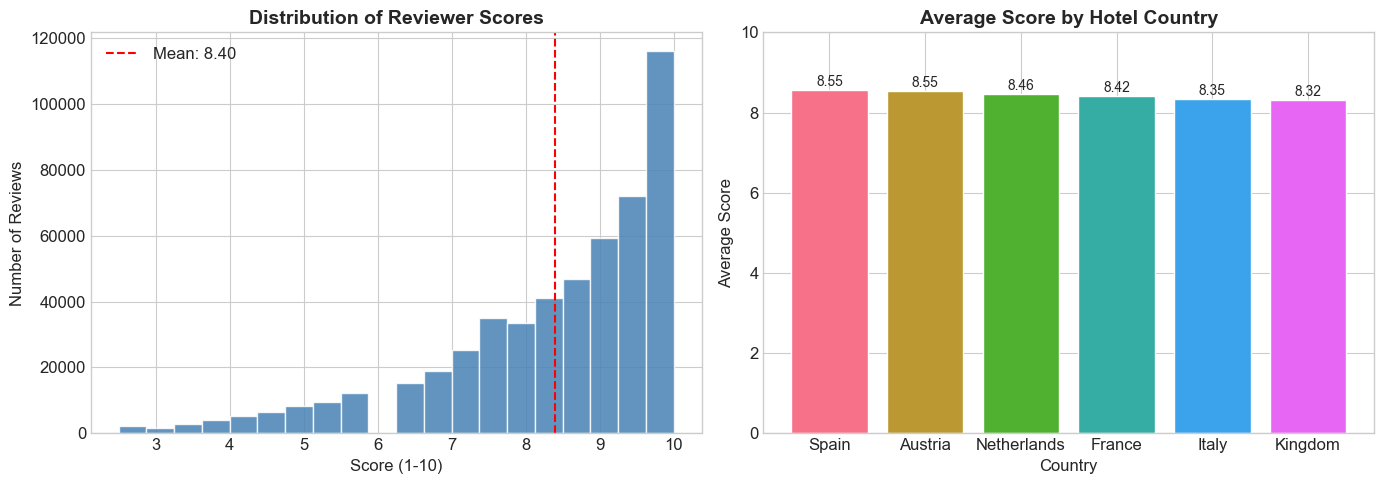

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of reviewer scores
axes[0].hist(df['Reviewer_Score'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Reviewer Scores', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score (1-10)')
axes[0].set_ylabel('Number of Reviews')
axes[0].axvline(df['Reviewer_Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["Reviewer_Score"].mean():.2f}')
axes[0].legend()

# Boxplot by country
score_by_country = df.groupby('Hotel_Country')['Reviewer_Score'].mean().sort_values(ascending=False)
axes[1].bar(score_by_country.index, score_by_country.values, color=sns.color_palette('husl', len(score_by_country)))
axes[1].set_title('Average Score by Hotel Country', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Average Score')
axes[1].set_ylim(0, 10)
for i, v in enumerate(score_by_country.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()

plt.show()

## 6. Top & Bottom Hotels

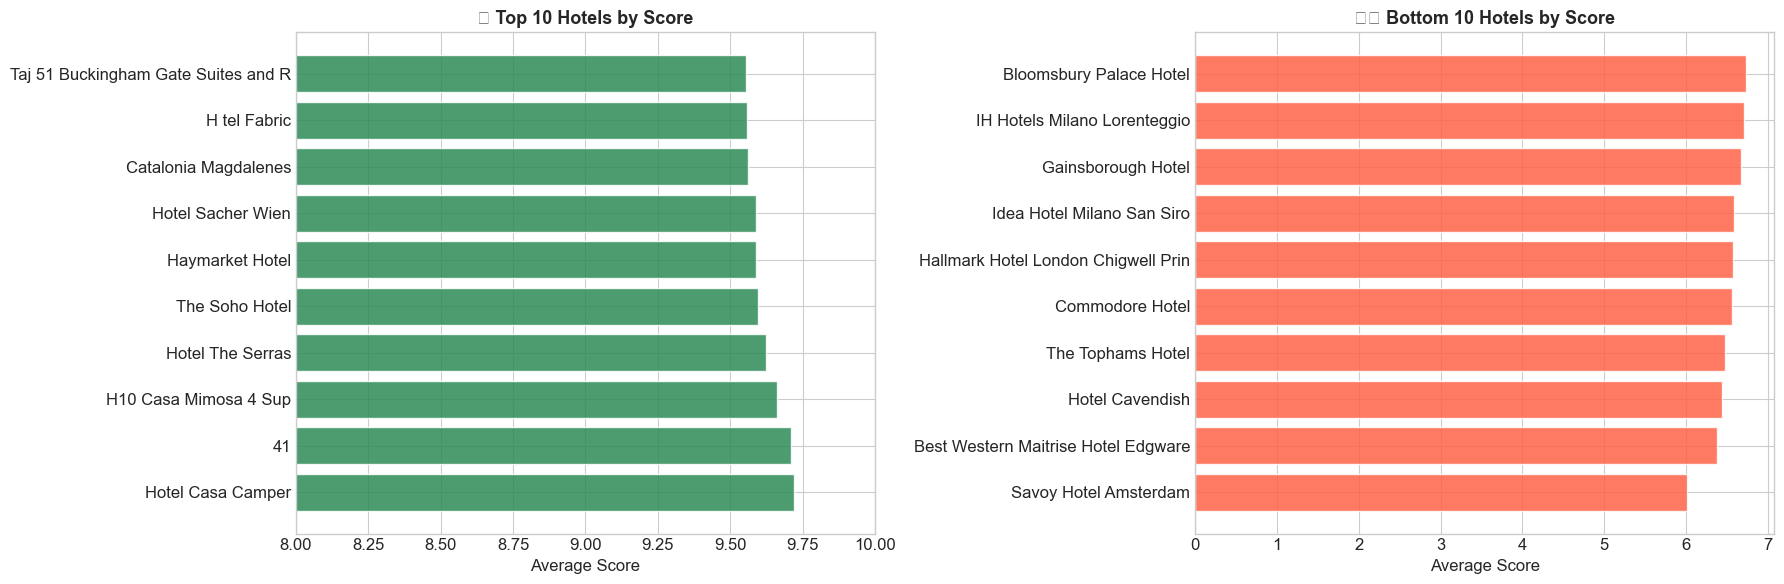

In [13]:
# Hotels with at least 100 reviews for reliability
hotel_stats = df.groupby('Hotel_Name').agg(
    avg_score=('Reviewer_Score', 'mean'),
    review_count=('Reviewer_Score', 'count'),
    country=('Hotel_Country', 'first')
).reset_index()

reliable_hotels = hotel_stats[hotel_stats['review_count'] >= 100]

top10 = reliable_hotels.nlargest(10, 'avg_score')
bot10 = reliable_hotels.nsmallest(10, 'avg_score')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10
axes[0].barh(top10['Hotel_Name'].str[:35], top10['avg_score'], color='seagreen', alpha=0.85)
axes[0].set_title('🏆 Top 10 Hotels by Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Score')
axes[0].set_xlim(8, 10)

# Bottom 10
axes[1].barh(bot10['Hotel_Name'].str[:35], bot10['avg_score'], color='tomato', alpha=0.85)
axes[1].set_title('⚠️ Bottom 10 Hotels by Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Score')

plt.tight_layout()

plt.show()

## 7. Seasonality Analysis

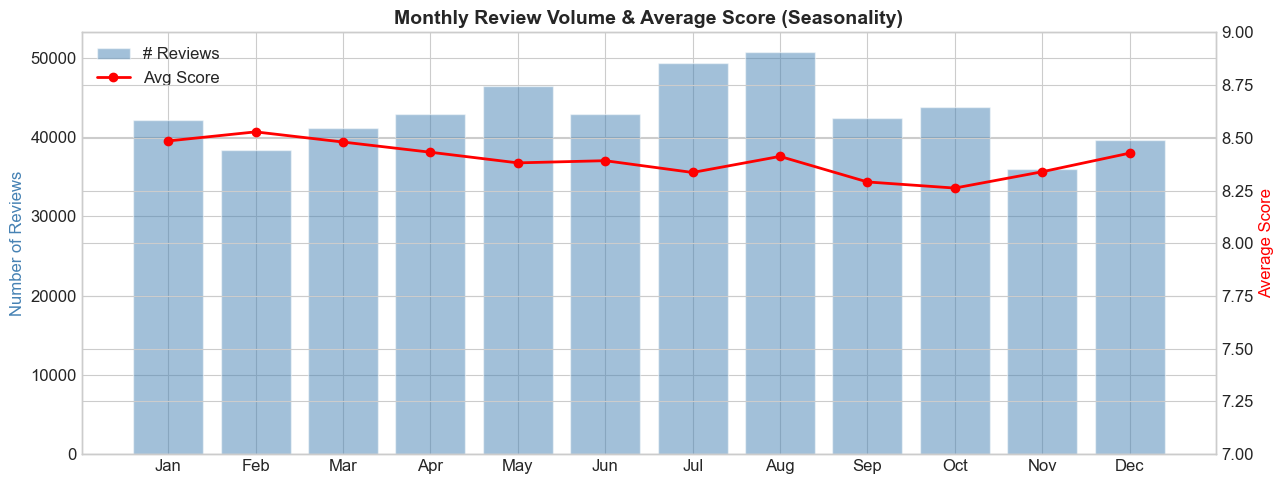

In [14]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('Review_MonthName').agg(
    avg_score=('Reviewer_Score', 'mean'),
    review_count=('Reviewer_Score', 'count')
).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

bars = ax1.bar(monthly.index, monthly['review_count'], color='steelblue', alpha=0.5, label='# Reviews')
line = ax2.plot(monthly.index, monthly['avg_score'], color='red', marker='o', linewidth=2, label='Avg Score')

ax1.set_title('Monthly Review Volume & Average Score (Seasonality)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Reviews', color='steelblue')
ax2.set_ylabel('Average Score', color='red')
ax2.set_ylim(7, 9)

lines = [bars] + line
labels = ['# Reviews', 'Avg Score']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()

plt.show()

## 8. Reviewer Nationality Analysis

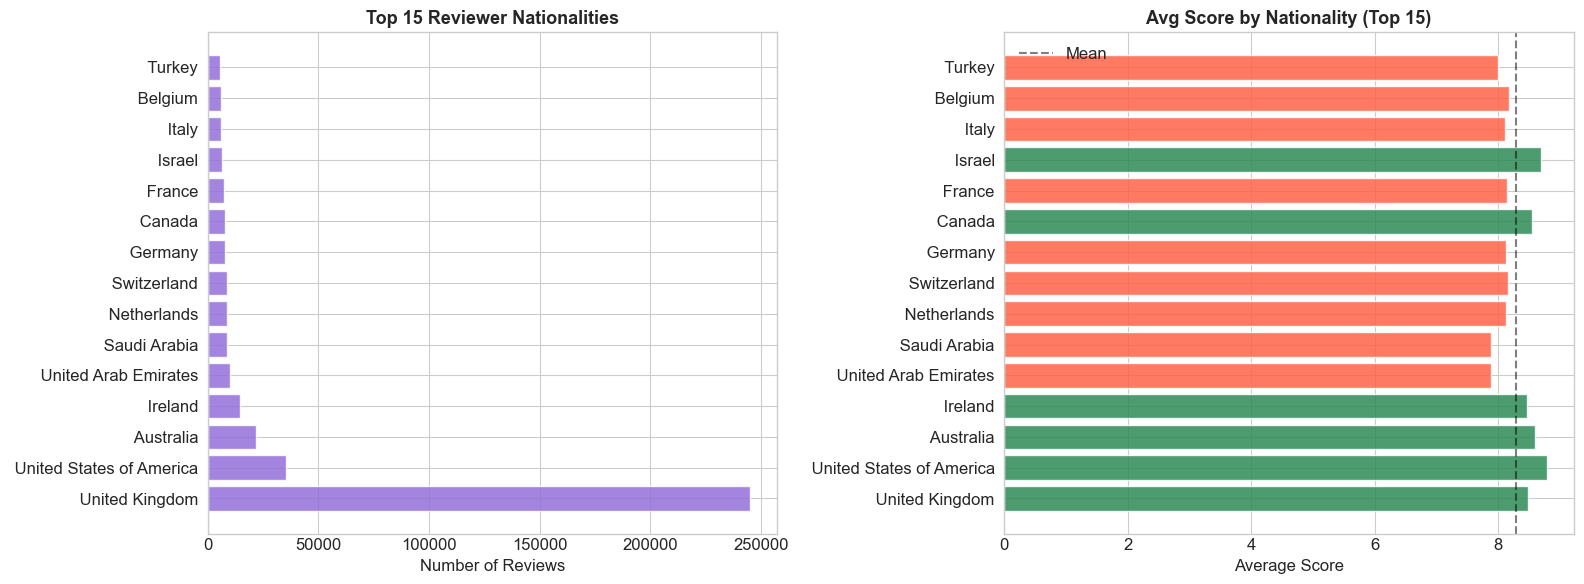

In [16]:
top_nationalities = df['Reviewer_Nationality'].value_counts().head(15)

avg_score_by_nationality = df.groupby('Reviewer_Nationality')['Reviewer_Score'].mean()
top_nat_scores = avg_score_by_nationality[top_nationalities.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_nationalities.index, top_nationalities.values, color='mediumpurple', alpha=0.85)
axes[0].set_title('Top 15 Reviewer Nationalities', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')

colors = ['seagreen' if v >= top_nat_scores.mean() else 'tomato' for v in top_nat_scores.values]
axes[1].barh(top_nat_scores.index, top_nat_scores.values, color=colors, alpha=0.85)
axes[1].set_title('Avg Score by Nationality (Top 15)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Score')
axes[1].axvline(top_nat_scores.mean(), color='black', linestyle='--', alpha=0.5, label='Mean')
axes[1].legend()

plt.tight_layout()

plt.show()

## 9. Summary Statistics
---

In [17]:
print('=' * 50)
print('📊 HOTEL QUALITY — EDA SUMMARY')
print('=' * 50)
print(f'Total Reviews        : {len(df):,}')
print(f'Unique Hotels        : {df["Hotel_Name"].nunique():,}')
print(f'Countries Covered    : {df["Hotel_Country"].nunique()}')
print(f'Date Range           : {df["Review_Date"].min().date()} → {df["Review_Date"].max().date()}')
print(f'Average Score        : {df["Reviewer_Score"].mean():.2f} / 10')
print(f'Median Score         : {df["Reviewer_Score"].median():.2f} / 10')
print(f'Reviews with Negative: {(df["Negative_Review"] != "").sum():,} ({(df["Negative_Review"] != "").mean()*100:.1f}%)')
print(f'Reviews with Positive: {(df["Positive_Review"] != "").sum():,} ({(df["Positive_Review"] != "").mean()*100:.1f}%)')
print('=' * 50)
print('✅ Phase 1 Complete! → Proceed to 02_Complaint_Categorization.ipynb')

📊 HOTEL QUALITY — EDA SUMMARY
Total Reviews        : 515,738
Unique Hotels        : 1,492
Countries Covered    : 6
Date Range           : 2015-08-04 → 2017-08-03
Average Score        : 8.40 / 10
Median Score         : 8.80 / 10
Reviews with Negative: 387,848 (75.2%)
Reviews with Positive: 479,792 (93.0%)
✅ Phase 1 Complete! → Proceed to 02_Complaint_Categorization.ipynb
